# Project 3: Monthly Sales Trends and Analysis

**Objective:** Identify sales trends over time.

**Tasks:**
1. Calculate monthly sales totals and display them in a line chart.
2. Identify the best and worst months for sales.
3. Analyze sales by region using a bar chart.

---
## 1. Import Libraries & Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

df = pd.read_csv('product_sales_dataset_final.csv')
df.columns = df.columns.str.strip()

# parse the date column (format is MM-DD-YY)
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%m-%d-%y')
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Month_Name'] = df['Order_Date'].dt.strftime('%b')
df['YearMonth'] = df['Order_Date'].dt.to_period('M')

print('Shape:', df.shape)
print('Date range:', df['Order_Date'].min(), 'to', df['Order_Date'].max())
print('Regions:', df['Region'].unique())
df.head()


Shape: (200000, 18)
Date range: 2023-01-01 00:00:00 to 2024-12-31 00:00:00
Regions: ['South' 'Centre' 'East' 'West']


,Order_ID,Order_Date,Customer_Name,City,State,Region,Country,Category,Sub_Category,Product_Name,Quantity,Unit_Price,Revenue,Profit,Year,Month,Month_Name,YearMonth
0,1,2023-08-23,Bianca Brown,Jackson,Mississippi,South,United States,Accessories,Small Electronics,Phone Case,3,201.01,603.03,221.49,2023,8,Aug,2023-08
1,2,2024-12-20,Jared Edwards,Grand Rapids,Michigan,Centre,United States,Accessories,Small Electronics,Charging Cable,4,74.30,297.20,97.09,2024,12,Dec,2024-12
2,3,2024-01-29,Susan Valdez,Minneapolis,Minnesota,Centre,United States,Clothing & Apparel,Sportswear,Nike Air Force 1,1,68.19,68.19,25.47,2024,1,Jan,2024-01
3,4,2024-11-29,Tina Williams,Tallahassee,Florida,South,United States,Clothing & Apparel,Sportswear,Adidas Tracksuit,3,209.64,628.92,231.38,2024,11,Nov,2024-11
4,5,2023-09-21,Catherine Gordon,Baltimore,Maryland,East,United States,Accessories,Bags,Backpack,1,216.63,216.63,42.46,2023,9,Sep,2023-09


---
## 2. Calculate Monthly Sales Totals

In [2]:
# group by year-month and add up revenue, profit and number of orders
monthly = df.groupby('YearMonth').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Orders=('Order_ID', 'count')
).reset_index()

monthly = monthly.sort_values('YearMonth')
monthly['YearMonth_str'] = monthly['YearMonth'].astype(str)

print(monthly[['YearMonth_str', 'Total_Revenue', 'Total_Profit', 'Orders']])


   YearMonth_str  Total_Revenue  Total_Profit  Orders
0        2023-01     4379894.64     974780.12    6119
1        2023-02     2769477.21     619228.38    3859
2        2023-03     3885192.59     867726.10    5542
3        2023-04     4347474.27     958930.58    6003
4        2023-05     4848240.62    1071356.86    6750
5        2023-06     4688298.85    1043290.92    6683
6        2023-07     4515605.37     996907.78    6313
7        2023-08     4379811.63     957470.81    6148
8        2023-09     4622595.68    1022311.01    6482
9        2023-10     8677394.98    1933008.35   12403
10       2023-11    13368079.89    2953712.93   18915
11       2023-12    10273306.93    2280238.15   14590
12       2024-01     4367352.84     968323.27    6048
13       2024-02     2930941.45     655968.48    3974
14       2024-03     4088588.81     906402.31    5699
15       2024-04     4263479.24     940946.64    6025
16       2024-05     4883303.43    1089304.88    6805
17       2024-06     4721684

---
## 3. Task 1 — Monthly Sales Trend (Line Chart)

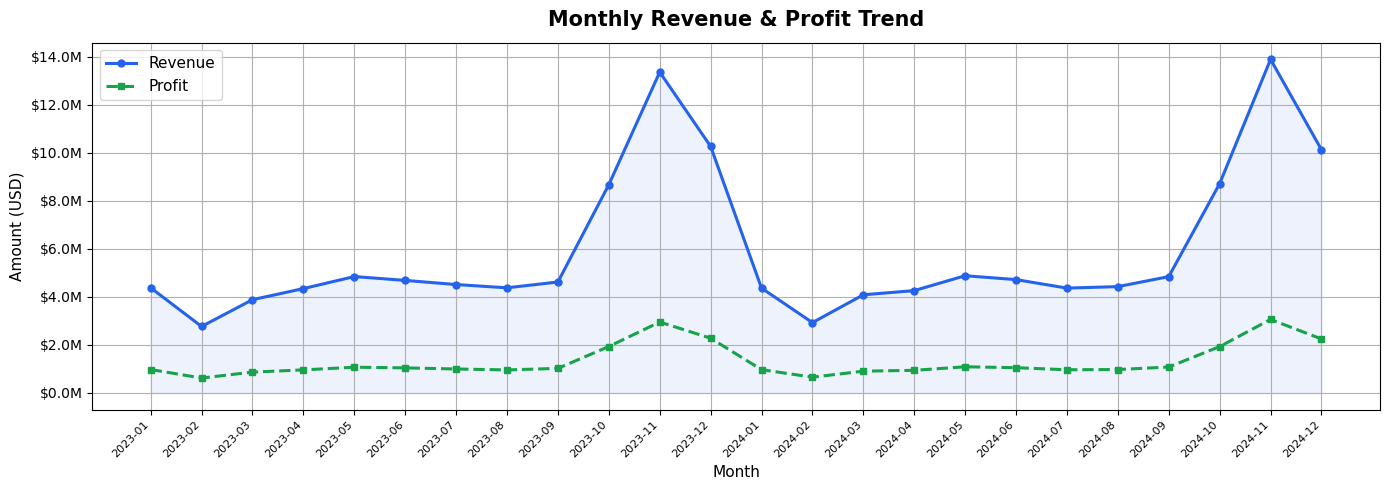

saved chart as monthly_trend.png


In [12]:
fig, ax = plt.subplots(figsize=(14, 5))

x = range(len(monthly))

ax.plot(x, monthly['Total_Revenue'], color='#2563EB', linewidth=2.2,
        marker='o', markersize=5, label='Revenue')
ax.plot(x, monthly['Total_Profit'], color='#16A34A', linewidth=2.2,
        marker='s', markersize=5, linestyle='--', label='Profit')

ax.fill_between(x, monthly['Total_Revenue'], alpha=0.08, color='#2563EB')

ax.set_xticks(x)
ax.set_xticklabels(monthly['YearMonth_str'], rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1_000_000:.1f}M'))
ax.set_title('Monthly Revenue & Profit Trend', fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Amount (USD)', fontsize=11)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150, bbox_inches='tight')
plt.grid(True)
plt.show()
print('saved chart as monthly_trend.png')


---
## 4. Task 2 — Best & Worst Months for Sales

In [4]:
# find the rows with max and min revenue
best_month = monthly.loc[monthly['Total_Revenue'].idxmax()]
worst_month = monthly.loc[monthly['Total_Revenue'].idxmin()]

print('Best month:', best_month['YearMonth_str'])
print('  Revenue:', best_month['Total_Revenue'])
print('  Profit:', best_month['Total_Profit'])
print('  Orders:', best_month['Orders'])
print()
print('Worst month:', worst_month['YearMonth_str'])
print('  Revenue:', worst_month['Total_Revenue'])
print('  Profit:', worst_month['Total_Profit'])
print('  Orders:', worst_month['Orders'])


Best month: 2024-11
  Revenue: 13899671.91
  Profit: 3062304.22
  Orders: 19469

Worst month: 2023-02
  Revenue: 2769477.21
  Profit: 619228.38
  Orders: 3859


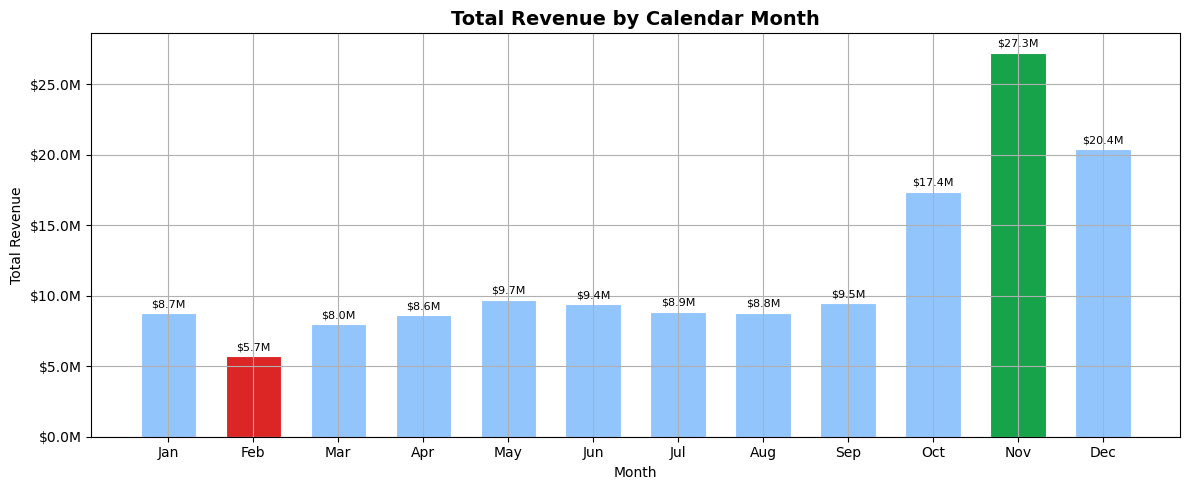

saved chart as best_worst_months.png


In [11]:
# now look at total revenue per calendar month (combining all years)
avg_by_month = df.groupby('Month')['Revenue'].sum().reset_index()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# pick colors - highlight the highest and lowest bars
colors = []
for m in range(len(avg_by_month)):
    if m == avg_by_month['Revenue'].idxmin():
        colors.append('#DC2626')
    elif m == avg_by_month['Revenue'].idxmax():
        colors.append('#16A34A')
    else:
        colors.append('#93C5FD')

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(month_labels, avg_by_month['Revenue'], color=colors,
               edgecolor='white', linewidth=0.8, width=0.65)

for bar, val in zip(bars, avg_by_month['Revenue']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + avg_by_month['Revenue'].max()*0.01,
            f'${val/1e6:.1f}M', ha='center', va='bottom', fontsize=8)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1e6:.1f}M'))
ax.set_title('Total Revenue by Calendar Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue')

plt.tight_layout()
plt.savefig('best_worst_months.png', dpi=150, bbox_inches='tight')
plt.grid(True)
plt.show()
print('saved chart as best_worst_months.png')


---
## 5. Task 3 — Sales by Region (Bar Chart)

In [6]:
# group everything by region
region = df.groupby('Region').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Orders=('Order_ID', 'count')
).reset_index()

region = region.sort_values('Total_Revenue', ascending=False)
region['Profit_Margin_%'] = (region['Total_Profit'] / region['Total_Revenue'] * 100).round(1)

print(region)


   Region  Total_Revenue  Total_Profit  Orders  Profit_Margin_%
1    East    44980048.22    9221327.43   57034             20.5
3    West    36242841.73    8313962.76   55428             22.9
0  Centre    36081894.34    8094863.77   49603             22.4
2   South    25102960.64    5918454.17   37935             23.6


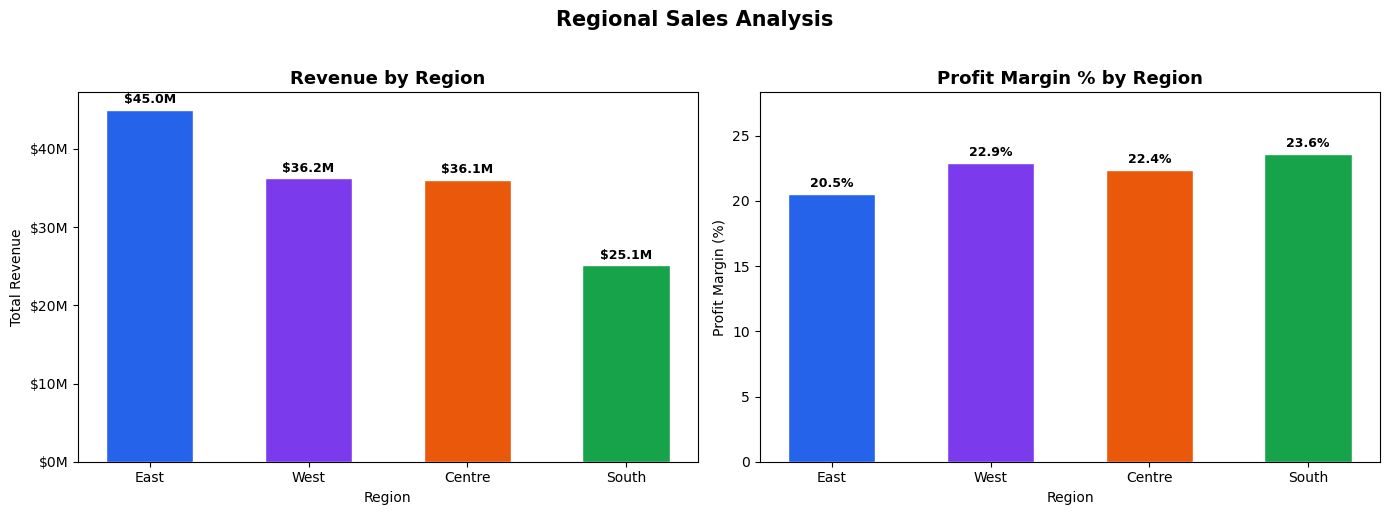

saved chart as region_analysis.png


In [15]:
region_colors = ['#2563EB', '#7C3AED', '#EA580C', '#16A34A']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# revenue by region
ax1 = axes[0]
bars1 = ax1.bar(region['Region'], region['Total_Revenue'], color=region_colors,
                edgecolor='white', width=0.55)
for bar, val in zip(bars1, region['Total_Revenue']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + region['Total_Revenue'].max()*0.01,
             f'${val/1e6:.1f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1e6:.0f}M'))
ax1.set_title('Revenue by Region', fontsize=13, fontweight='bold')
ax1.set_xlabel('Region')
ax1.set_ylabel('Total Revenue')

# profit margin by region
ax2 = axes[1]
bars2 = ax2.bar(region['Region'], region['Profit_Margin_%'], color=region_colors,
                edgecolor='white', width=0.55)
for bar, val in zip(bars2, region['Profit_Margin_%']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_title('Profit Margin % by Region', fontsize=13, fontweight='bold')
ax2.set_xlabel('Region')
ax2.set_ylabel('Profit Margin (%)')
ax2.set_ylim(0, region['Profit_Margin_%'].max() * 1.2)

plt.suptitle('Regional Sales Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('region_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved chart as region_analysis.png')


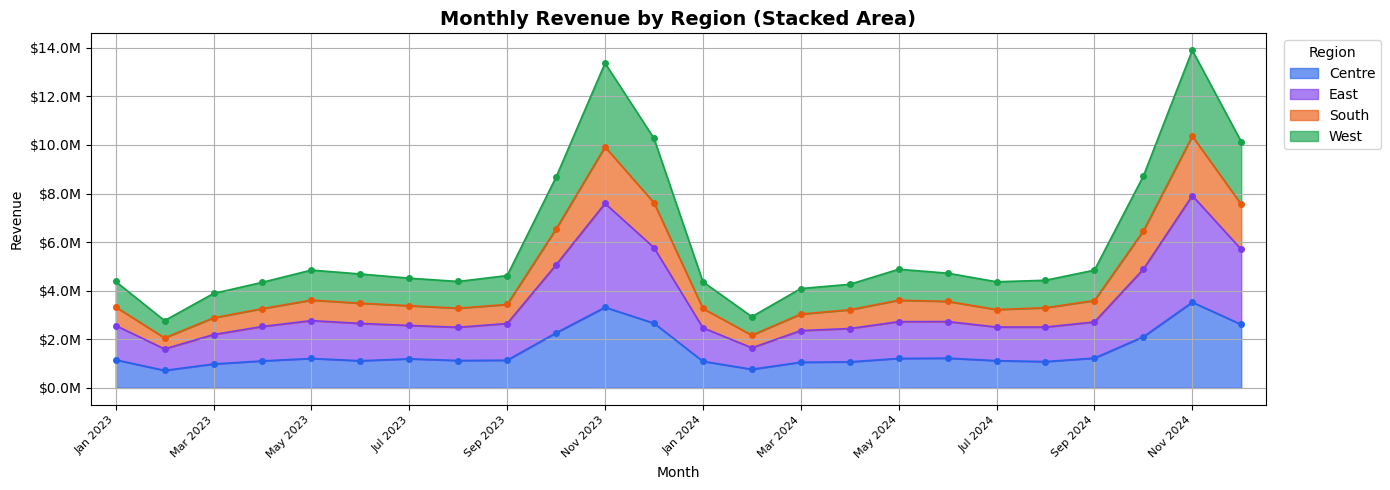

saved chart as monthly_region_stacked.png


In [17]:
# monthly revenue split by region (stacked area chart)
monthly_region = df.groupby(['YearMonth', 'Region'])['Revenue'].sum().unstack('Region').sort_index()
monthly_region.index = monthly_region.index.to_timestamp()

x = np.arange(len(monthly_region))
bottom = np.zeros(len(monthly_region))

fig, ax = plt.subplots(figsize=(14, 5))

for col, color in zip(monthly_region.columns, region_colors):
    vals = monthly_region[col].values
    ax.fill_between(x, bottom, bottom + vals, alpha=0.65, color=color, label=col)
    ax.plot(x, bottom + vals, color=color, linewidth=1.2, marker='o', markersize=4)
    bottom += vals

# only show every other month label so it doesn't get too crowded
labels = [d.strftime('%b %Y') for d in monthly_region.index]
tick_positions = list(range(0, len(labels), 2))
ax.set_xticks(tick_positions)
ax.set_xticklabels([labels[i] for i in tick_positions], rotation=45, ha='right', fontsize=8)
ax.set_xlim(-0.5, len(x) - 0.5)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1e6:.1f}M'))
ax.set_title('Monthly Revenue by Region (Stacked Area)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue')
ax.legend(title='Region', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('monthly_region_stacked.png', dpi=150, bbox_inches='tight')
plt.grid(True)
plt.show()
print('saved chart as monthly_region_stacked.png')

---
## 6. Summary

In [9]:
total_rev = df['Revenue'].sum()
total_profit = df['Profit'].sum()
total_orders = len(df)
top_region = region.iloc[0]

print('Total Revenue:', total_rev)
print('Total Profit:', total_profit)
print('Overall Profit Margin (%):', total_profit / total_rev * 100)
print('Total Orders:', total_orders)
print()
print('Best Month (Revenue):', best_month['YearMonth_str'], '-', best_month['Total_Revenue'])
print('Worst Month (Revenue):', worst_month['YearMonth_str'], '-', worst_month['Total_Revenue'])
print()
print('Top Region:', top_region['Region'], '-', top_region['Total_Revenue'])


Total Revenue: 142407744.93
Total Profit: 31548608.13
Overall Profit Margin (%): 22.153716531012833
Total Orders: 200000

Best Month (Revenue): 2024-11 - 13899671.91
Worst Month (Revenue): 2023-02 - 2769477.21

Top Region: East - 44980048.22
